
**First things first** - please go to 'File' and select 'Save a copy in Drive' so that you have your own version of this activity set up and ready to use.
Remember to update your Course 1 notebook with links to your own work once completed!

Mini-project 5.3 Detecting the anomalous activity of a ship’s engine

This mini-project allows you to dive deep into a real-world challenge, applying and honing the data science skills you've been cultivating so far. In this immersive exploration into detecting the anomalous activity of a ship’s engine, you can practically apply the concepts you've learned over the past few weeks.

A poorly maintained ship engine in the supply chain industry can lead to inefficiencies, increased fuel consumption, higher risks of malfunctions, and potential safety hazards. Your challenge in this project is to apply critical thinking and ML concepts to design and implement a robust anomaly detection model.

<br></br>

## **Business context**
You are provided with a real data set to identify anomalous activity in a ship’s engine functionality (Devabrat,  2022). As you work through this project, keep in mind that, typically speaking, anomalies would make up a minority of the data points (i.e., about 1% to 5% of the data points would be anomalies).

The data set contains six important features continuously monitored to evaluate the engine's status as ‘good’ or ‘bad’. These features are:
- **Engine rpm (revolutions per minute):** A high rpm indicates the engine is operating at a higher speed than designed for prolonged periods, which can lead to overheating, excessive wear, and eventual failure. A low rpm could signal a lack of power, issues with fuel delivery, or internal mechanical problems.
- **Lubrication oil pressure:** Low lubrication oil pressure indicates insufficient lubrication, leading to increased friction, overheating, and engine damage. A high lubrication oil pressure could signal a blockage in the oil delivery system, potentially causing seal or gasket failure.
- **Fuel pressure:** High fuel pressure can cause poor engine performance and incomplete combustion, indicating fuel pump or filter issues. A low fuel pressure may result in excessive fuel consumption, poor emissions, or damage to the fuel injectors.
- **Coolant pressure:** Low coolant pressure indicates a potential leak in the cooling system or a coolant pump failure, risking engine overheating. A high coolant pressure could be a sign of a blockage in the cooling system or a failing head gasket, which can also lead to overheating.
- **Lubrication oil temperature:** High lubrication oil temperature suggests the oil is overheating, which can degrade its lubricating properties and lead to engine damage. A low lubrication oil temperature may indicate it is not reaching its optimal operating temperature, potentially causing inadequate lubrication.
- **Coolant temperature:** High coolant temperature signals overheating, which various issues, including a failed thermostat, coolant leak, or insufficient coolant flow can cause. A low coolant temperature could suggest the engine is not reaching its optimal operating temperature, affecting performance and efficiency.

Issues with engines could lead to engine malfunctions, potential safety hazards, and downtime (e.g. delayed deliveries), resulting in the breakdown of a ship’s overall functionality, consequently impacting the business, such as affecting revenue via failure to deliver goods. By predicting timely maintenance, the business aims to increase profit by reducing downtime, reducing safety risks for the crew, limiting fuel consumption, and increasing customer satisfaction through timely deliveries.

Your task is to develop a robust anomaly detection system to protect a company’s shipping fleet by evaluating engine functionality. Therefore, you’ll explore the data and:
- employ preprocessing and feature engineering
- perform anomaly detection.

<br></br>

## **Objective**
By the end of this mini-project, you will be able to understand and apply statistical and ML methods for detecting anomalies.

In the Notebook, you will:
- explore the data set
- preprocess the data and conduct feature engineering
- apply statistical techniques to detect anomalies
- use ML algorithms to detect anomalies.

<br></br>

## **Assessment criteria**
By completing this project, you will be able to provide evidence that you can:
- demonstrate enhanced problem-solving skills and proposed strategic solutions by systematically analysing complex organisational challenges
- identify meaningful patterns in complex data to evidence advanced critical and statistical thinking skills
- select statistical techniques appropriate to a solutions design approach and evidence the ability to evaluate their effectiveness
- demonstrate enhanced data representation and improved model performance by systematically implementing relevant techniques
- design innovative solutions through critically selecting, evaluating and implementing effective unsupervised learning techniques.

<br></br>

## **Project guidance**
1. Import the required libraries and data set with the provided URL.
2. View the DataFrame and perform EDA, including identifying missing or duplicate values.
3. Generate the descriptive statistics of the data, including:
 - observing the mean for each feature
 - identifying the median
 - idenitfying the range values beyond the 95th percentile for at least two features.
4. Visualise the data to determine the distribution and extreme values.
5. Perform anomaly detection with a statistical method and identify possible anomalies. Specifically:
  - Use the interquartile range (IQR) method to identify outliers for each feature.
  - Create a new column (corresponding to each feature) that will indicate (in binary – 0,1) if the value of that feature is an outlier as per IQR calculations.
  - Use IQR to identify a sample as an outlier only if two or more of the features fall under an outlier category for a particular sample.
  - Record your thoughts and oberservations.
6. Perform anomaly detection with ML models:
  - Perform feature scaling to prepare the data for ML algorithms.
  - Using one-class SVM,
    - identify possible anomalies
    - visualise the output in 2D after performing PCA and ensure the outliers are in a different colour
    - apply different combinations of parameter settings to improve the model's outlier predictions to the expected 1-5%
    - record your insights about the use of this method.
  - Using Isolation Forest,
    - identify possible anomalies
    - visualise the output in 2D after performing PCA and ensure the outliers are in a different colour
    - apply different combinations of parameter settings to improve the model's outlier predictions to the expected 1-5%
    - record your insights about the use of this method.
7. Document your approach and major inferences from the data analysis and describe which method (and parameters) provided the best results and why.


#1a) Exploratory Data Analysis (EDA)

In [1]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
from scipy.stats import shapiro, median_abs_deviation
from sklearn.feature_selection import mutual_info_regression
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import OneClassSVM
from sklearn.ensemble import IsolationForest
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

import warnings
warnings.filterwarnings('ignore')

# URL to import data set from GitHub.
url = "https://raw.githubusercontent.com/JonP1997/Anomaly-Detection---Ships-Engine/refs/heads/main/Anomaly%20Data%20-%20Ship's%20Engine.csv"

Initial checks are to:
<li> view data frame (head() function)
<li> use the describe() and info() functions to check on mean, median, quartile ranges and any null values
<li> final formula checks for duplicated values

Overall, this shows analysis of 19535 x 6 DF

In [2]:
# Read the data.
df = pd.read_csv(url)
df.head()

,Engine rpm,Lub oil pressure,Fuel pressure,Coolant pressure,lub oil temp,Coolant temp
0,682,2.391656,4.617196,2.848982,76.272417,69.884609
1,605,5.466877,6.424361,5.727520,73.222679,74.907314
2,658,3.434232,3.680896,1.678708,88.089916,78.704806
3,749,2.094656,7.120927,1.639670,77.661625,82.386700
4,676,3.538228,5.956472,3.225336,75.226352,67.153220


In [3]:
df_length = len(df) # for use with anomaly % checks
df.describe(percentiles=[0.05, 0.95])

,Engine rpm,Lub oil pressure,Fuel pressure,Coolant pressure,lub oil temp,Coolant temp
count,19535.000000,19535.000000,19535.000000,19535.000000,19535.000000,19535.000000
mean,791.239263,3.303775,6.655615,2.335369,77.643420,78.427433
std,267.611193,1.021643,2.761021,1.036382,3.110984,6.206749
min,61.000000,0.003384,0.003187,0.002483,71.321974,61.673325
5%,443.000000,1.941852,3.127162,1.084493,74.269140,68.401196
50%,746.000000,3.162035,6.201720,2.166883,76.817350,78.346662
95%,1324.000000,5.058040,12.208475,4.438415,84.940778,88.612891
max,2239.000000,7.265566,21.138326,7.478505,89.580796,195.527912


In [4]:
df.info() # no null values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19535 entries, 0 to 19534
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Engine rpm        19535 non-null  int64  
 1   Lub oil pressure  19535 non-null  float64
 2   Fuel pressure     19535 non-null  float64
 3   Coolant pressure  19535 non-null  float64
 4   lub oil temp      19535 non-null  float64
 5   Coolant temp      19535 non-null  float64
dtypes: float64(5), int64(1)
memory usage: 915.8 KB


In [5]:
# Boolean mask: True for rows that are duplicates of previous rows
duplicates_mask = df.duplicated(keep=False)  # keep=False marks all duplicates

# Create DataFrame with only duplicate rows
df_duplicates = df[duplicates_mask]

print("Possible duplicate rows, if empty no duplicates:")
print(df_duplicates)

Possible duplicate rows, if empty no duplicates:
Empty DataFrame
Columns: [Engine rpm, Lub oil pressure, Fuel pressure, Coolant pressure, lub oil temp, Coolant temp]
Index: []


#1b) EDA Through Graphical/Visual Checks

First visual check for data is done through side by side comparisons of all 6 histogram plots of data for each feature of the data.

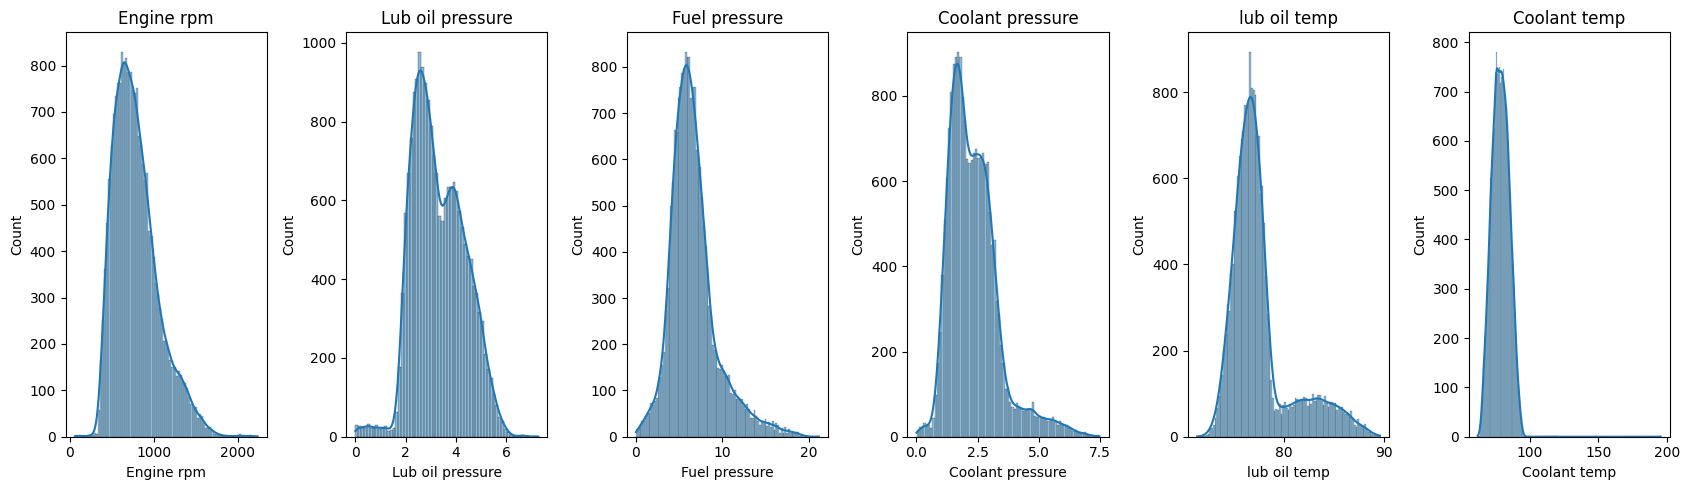

In [6]:
#need 6 distribution plots (histograms), 6 different box plots

cols = ['Engine rpm', 'Lub oil pressure', 'Fuel pressure','Coolant pressure','lub oil temp','Coolant temp']

# Create subplots (1 row, len(cols) columns)
fig, axs = plt.subplots(1, len(cols), figsize=(17, 5))

# Loop through columns
for i, col in enumerate(cols):
    sns.histplot(data=df[col], kde=True, ax=axs[i])
    axs[i].set_title(col)

plt.tight_layout()
plt.show()

Check into Q-Q plots to check for normality of data. First sign of outliers skewing data. Outliers in turn leading to left skewed / right skewed histograms

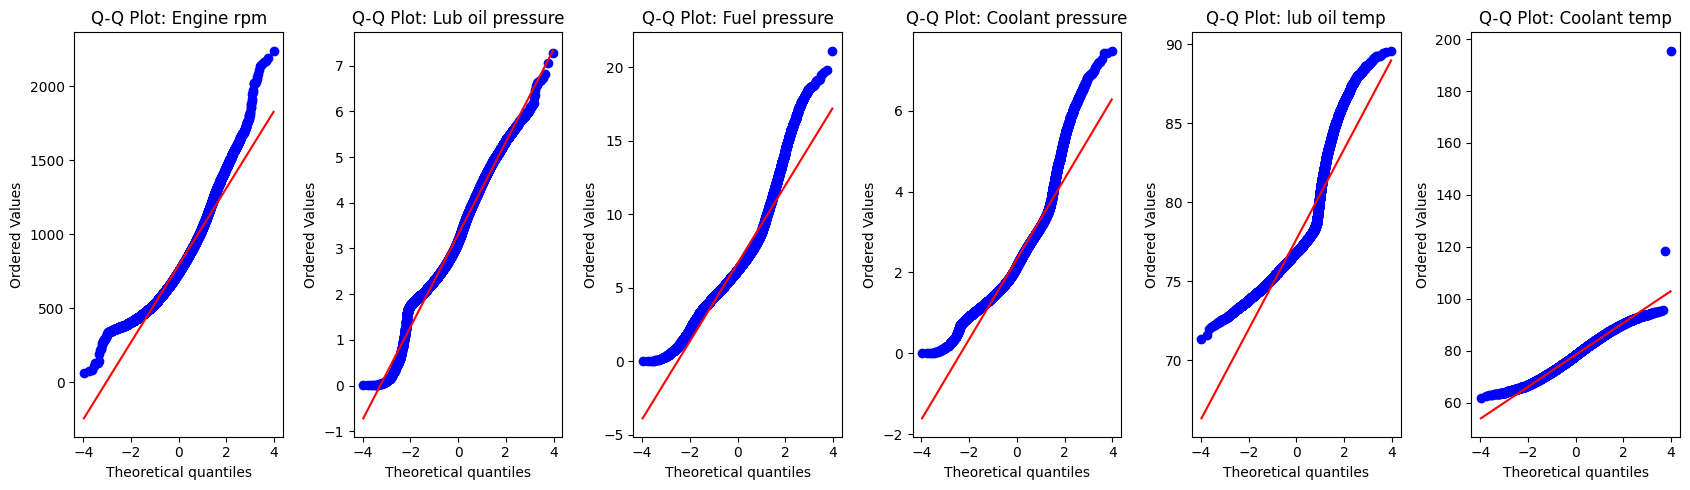

In [7]:
# Create subplots
fig, axs = plt.subplots(1, len(cols), figsize=(17, 5))

# Loop through each column
for i, col in enumerate(cols):
    stats.probplot(df[col], dist="norm", plot=axs[i])  # Q-Q plot
    axs[i].set_title(f'Q-Q Plot: {col}')

plt.tight_layout()
plt.show()

Finally, boxplots show IQR + outliers in data

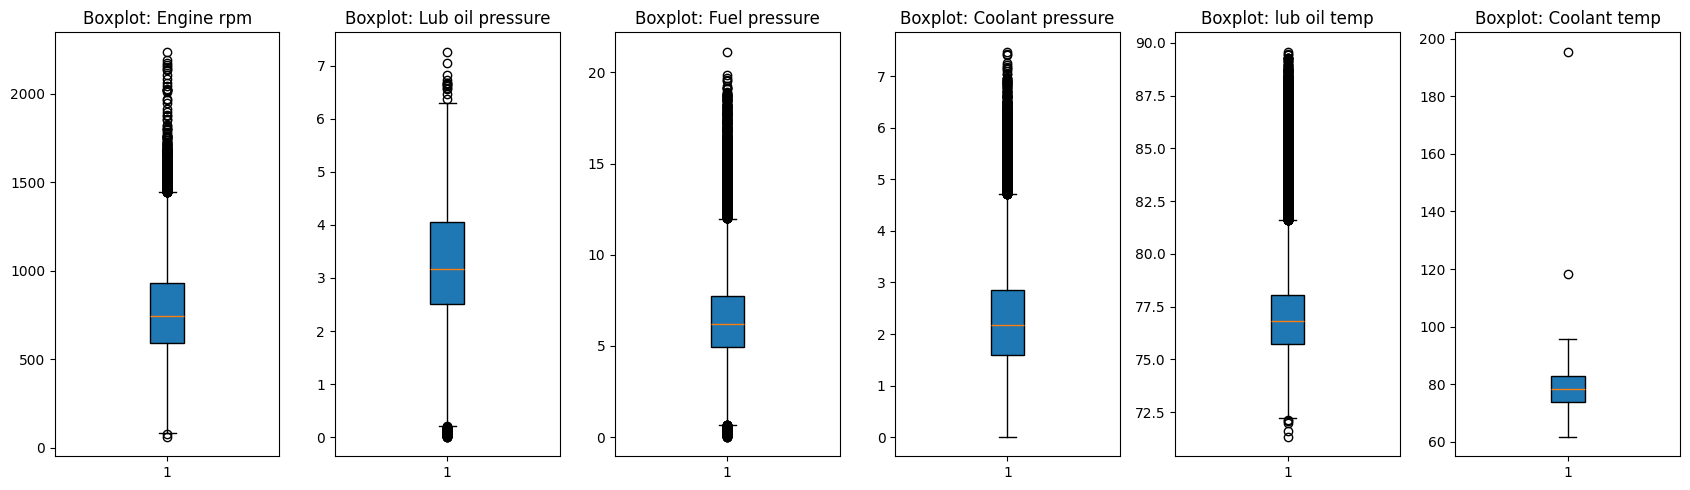

In [8]:
fig, axs = plt.subplots(1, len(cols), figsize=(17, 5))

# Loop through columns
for i, col in enumerate(cols):
    axs[i].boxplot(df[col], patch_artist=True)
    axs[i].set_title(f'Boxplot: {col}')

plt.tight_layout()
plt.show()

#2) IQR Statistical Method

Initial checks show that IQR isolates 14899 values within IQR across all features and 4636 as outliers. This does not reflect distribution, especially considering box plot for coolant shows low number for that feature alone

In [9]:
mask = pd.Series(True, index=df.index)  # start with all True
bounds = {}

for col in cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    bounds[col] = (lower_bound, upper_bound)

for col in cols:
    lower_bound, upper_bound = bounds[col]
    mask &= (df[col] >= lower_bound) & (df[col] <= upper_bound)

df_cleaned = df[mask].copy()

round(df_cleaned.describe(),3)

,Engine rpm,Lub oil pressure,Fuel pressure,Coolant pressure,lub oil temp,Coolant temp
count,14899.000,14899.000,14899.000,14899.000,14899.000,14899.000
mean,768.766,3.313,6.238,2.207,76.594,78.274
std,238.473,1.011,2.043,0.808,1.569,6.130
min,84.000,0.217,0.676,0.002,72.245,61.673
25%,586.000,2.524,4.862,1.584,75.553,73.715
50%,734.000,3.173,6.079,2.120,76.548,78.205
75%,916.000,4.057,7.442,2.771,77.476,82.766
max,1445.000,6.302,11.983,4.719,81.589,95.855


In [10]:
mask = pd.Series(False, index=df.index)  # start with all False

for col in cols:
    lower_bound, upper_bound = bounds[col]
    mask = mask | (df[col] < lower_bound) | (df[col] > upper_bound)

df_outliers = df[mask].copy()   # only outliers
round(df_outliers.describe(),3)

,Engine rpm,Lub oil pressure,Fuel pressure,Coolant pressure,lub oil temp,Coolant temp
count,4636.000,4636.000,4636.000,4636.000,4636.000,4636.000
mean,863.461,3.274,7.998,2.748,81.016,78.922
std,334.947,1.054,4.043,1.485,4.238,6.424
min,61.000,0.003,0.003,0.088,71.322,62.446
25%,615.000,2.509,5.162,1.647,76.803,74.405
50%,790.000,3.132,6.786,2.331,82.166,78.848
75%,1021.000,4.048,10.921,3.267,84.545,83.380
max,2239.000,7.266,21.138,7.479,89.581,195.528


Checking for a breakdown per feature of outliers to compare with 4636 obtained. In total 5069 individual outliers obtained, due to multiple outliers on certain rows, which are the point of interest. As such, expected number of rows with duplicate outliers is 5069-4636=433. So far, 23.7% of data found to have at least one outlier.

In [11]:
outlier_counts = {}
bounds ={}

for col in cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    bounds[col] = (lower_bound, upper_bound)

    # Count outliers
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    outlier_counts[col] = len(outliers)

# Create a summary table
outlier_table = pd.DataFrame.from_dict(outlier_counts, orient='index', columns=['Outlier Count'])
print(outlier_table)

                  Outlier Count
Engine rpm                  464
Lub oil pressure             66
Fuel pressure              1135
Coolant pressure            785
lub oil temp               2617
Coolant temp                  2


Formula to take table and add binary indications for outliers

In [12]:
df_iqr = df.copy()

for col in cols:
    # Compute IQR bounds
    Q1 = df_iqr[col].quantile(0.25)
    Q3 = df_iqr[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Create outlier flag column (1 = outlier, 0 = not outlier)
    df_iqr[col + '_outlier'] = ((df_iqr[col] < lower_bound) | (df_iqr[col] > upper_bound)).astype(int)

df_iqr.head()

,Engine rpm,Lub oil pressure,Fuel pressure,Coolant pressure,lub oil temp,Coolant temp,Engine rpm_outlier,Lub oil pressure_outlier,Fuel pressure_outlier,Coolant pressure_outlier,lub oil temp_outlier,Coolant temp_outlier
0,682,2.391656,4.617196,2.848982,76.272417,69.884609,0,0,0,0,0,0
1,605,5.466877,6.424361,5.727520,73.222679,74.907314,0,0,0,1,0,0
2,658,3.434232,3.680896,1.678708,88.089916,78.704806,0,0,0,0,1,0
3,749,2.094656,7.120927,1.639670,77.661625,82.386700,0,0,0,0,0,0
4,676,3.538228,5.956472,3.225336,75.226352,67.153220,0,0,0,0,0,0


Code to only select rows with more than 1 outlier

In [13]:
tHold = 2 # set threshold to capture and row ending outlier with >1 outliers
outlier_cols = [col for col in df_iqr.columns if col.endswith('_outlier')]
outlier_counts = df_iqr[outlier_cols].sum(axis=1)
df_with_outliers = df_iqr[outlier_counts >= tHold].copy()

df_with_outliers.head()

,Engine rpm,Lub oil pressure,Fuel pressure,Coolant pressure,lub oil temp,Coolant temp,Engine rpm_outlier,Lub oil pressure_outlier,Fuel pressure_outlier,Coolant pressure_outlier,lub oil temp_outlier,Coolant temp_outlier
113,1495,3.276230,3.714396,2.495264,85.053243,75.743004,1,0,0,0,1,0
122,1454,2.063374,6.168260,1.260121,83.372256,82.718247,1,0,0,0,1,0
131,830,3.231908,13.479172,2.568096,87.480362,73.428213,0,0,1,0,1,0
144,1762,1.697487,4.327845,2.523372,86.750349,82.393211,1,0,0,0,1,0
148,1494,2.443220,3.548139,1.953403,82.234541,83.953914,1,0,0,0,1,0


In [14]:
df_with_outliers.describe()

,Engine rpm,Lub oil pressure,Fuel pressure,Coolant pressure,lub oil temp,Coolant temp,Engine rpm_outlier,Lub oil pressure_outlier,Fuel pressure_outlier,Coolant pressure_outlier,lub oil temp_outlier,Coolant temp_outlier
count,422.000000,422.000000,422.000000,422.000000,422.000000,422.000000,422.000000,422.000000,422.000000,422.000000,422.000000,422.0
mean,997.966825,3.301546,10.035768,3.507300,82.828350,79.284659,0.265403,0.042654,0.514218,0.405213,0.798578,0.0
std,413.458329,1.164565,4.743275,1.806355,3.547605,6.045495,0.442072,0.202316,0.500391,0.491516,0.401538,0.0
min,77.000000,0.007891,0.045126,0.370904,74.196593,63.287928,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
25%,661.750000,2.513900,5.938813,1.786018,81.944765,74.963337,0.000000,0.000000,0.000000,0.000000,1.000000,0.0
50%,881.500000,3.222578,10.820402,2.913121,83.415170,79.702829,0.000000,0.000000,1.000000,0.000000,1.000000,0.0
75%,1451.500000,4.152563,13.787472,5.224599,85.240841,83.579763,1.000000,0.000000,1.000000,1.000000,1.000000,0.0
max,2106.000000,6.615159,19.858917,7.097571,89.140394,93.281480,1.000000,1.000000,1.000000,1.000000,1.000000,0.0


Check to see what percentage of data found through IQR method is anomaly, to reference vs 1-5% outlined in problem statement

In [15]:
outlier_no_of_rows = len(df_with_outliers)
anomaly_IQR = round(outlier_no_of_rows/df_length*100,3)
print(anomaly_IQR,'% of data through IQR detected as anokmlaies for n>1 anomaly rows')

2.16 % of data through IQR detected as anokmlaies for n>1 anomaly rows


Overall, IQR method results in 2.16% of data being flagged as anomalies. Basis input from industry expert, this is within expected range of outlier values, showing how IQR method can give a good indication of outliers. It is worth noting that basis this, outliers values where only column is outside of quartile ranges are ignored / assumed to be accepted, and will not cover extreme outliers as a problem (example includes maximum value for coolant temp,which significantly differs from IQR for data, but as is the only outlier for that row flagged as acceptable).

#3) One Class SVM Method

Step 1 - scale the data so it can be used for PCA

In [16]:
X = df.copy()
# X.head()

scaler = StandardScaler()

scaled_data = scaler.fit_transform(X)

df_scaled = pd.DataFrame(scaled_data, columns=X.columns)
df_scaled.head()

,Engine rpm,Lub oil pressure,Fuel pressure,Coolant pressure,lub oil temp,Coolant temp
0,-0.408212,-0.892819,-0.738304,0.495596,-0.440709,-1.376412
1,-0.695950,2.117332,-0.083759,3.273154,-1.421047,-0.567158
2,-0.497896,0.127697,-1.077426,-0.633625,3.358026,0.044690
3,-0.157842,-1.183534,0.168533,-0.671293,0.005852,0.637913
4,-0.430633,0.229492,-0.253226,0.858747,-0.776966,-1.816491


Below are to assess difference between OCSVM between data before and after PCA, to understand how this can affect model. Observed change in % of anomalies after PCA. Overall, OCSVM model needs to use y_pred_ocsvm before PCA, to reduce issue of data loss / reduced accuracy after data dimensions are reduced

The anomaly labels predicted by OCSVM on the full standardized 6-feature dataset were then appended to the 2D PCA projection for visualisation.

Three individual OCSVM parameters were used in model testing, results captured in report. Code was not repeated three time individually, but altered for each iteration. OCSVM values used were as follows:
<li> gamma = 0.05, nu = 0.05, outlier percentage = 5%
<li> gamma = 0.12, nu = 0.01, outlier percentage = 1%
<li> gamma = 0.4, nu = 0.01, outlier percentage = 2.16% (this gives 434 outliers, same proportion of outliers found in IQR method for comparison)

In [17]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(df_scaled)

In [18]:
print("Normalised data: ", df_scaled.shape)
print("PCA data for visualisation: ", X_pca.shape)

Normalised data:  (19535, 6)
PCA data for visualisation:  (19535, 2)


This compares anomaly detection before and after PCA, showing why OCSVM should be fit on the full standardized feature set rather than on PCA-reduced data.

In [19]:
model1 = OneClassSVM(kernel='rbf', gamma=0.05, nu=0.05)
model1.fit(df_scaled)
y_pred_ocsvm1 = model1.predict(df_scaled)
y_pred_ocsvm1.shape

(19535,)

In [20]:
values, counts = np.unique(y_pred_ocsvm1, return_counts=True)
clean_dict1 = {int(v): int(c) for v, c in zip(values, counts)}
print(clean_dict1)
print("percentage of data flagged as anomales before pca: ",counts[0]/19535*100)

{-1: 978, 1: 18557}
percentage of data flagged as anomales before pca:  5.006398771435884


In [21]:
model2 = OneClassSVM(kernel='rbf', gamma=0.12, nu=0.01)
model2.fit(df_scaled)
y_pred_ocsvm2 = model2.predict(df_scaled)
y_pred_ocsvm2.shape

(19535,)

In [22]:
values, counts = np.unique(y_pred_ocsvm2, return_counts=True)
clean_dict2 = {int(v): int(c) for v, c in zip(values, counts)}
print(clean_dict2)
print("percentage of data flagged as anomales before pca: ",counts[0]/19535*100)

{-1: 197, 1: 19338}
percentage of data flagged as anomales before pca:  1.0084463782953672


In [23]:
model3 = OneClassSVM(kernel='rbf', gamma=0.396, nu=0.01)
model3.fit(df_scaled)
y_pred_ocsvm3 = model3.predict(df_scaled)
y_pred_ocsvm3.shape

(19535,)

In [24]:
values, counts = np.unique(y_pred_ocsvm3, return_counts=True)
clean_dict3 = {int(v): int(c) for v, c in zip(values, counts)}
print(clean_dict3)
print("percentage of data flagged as anomales before pca: ",counts[0]/19535*100)

{-1: 422, 1: 19113}
percentage of data flagged as anomales before pca:  2.160225236754543


OCSVM model was trained on all 6 rows for outliers. Here, these results are added back onto PCA table

In [25]:
df_pca = pd.DataFrame(X_pca,columns=['PC1','PC2'])
ocsvm_table1 = df_pca.copy() #keeping df_pca separate so that anomaly values from other models i.e. Isolation Forest can be added onto it
ocsvm_table2 = df_pca.copy()
ocsvm_table3 = df_pca.copy()

ocsvm_table1['anomaly'] = y_pred_ocsvm1
ocsvm_table2['anomaly'] = y_pred_ocsvm2
ocsvm_table3['anomaly'] = y_pred_ocsvm3
ocsvm_table1.describe()

,PC1,PC2,anomaly
count,1.953500e+04,1.953500e+04,19535.000000
mean,2.691588e-17,-2.400605e-17,0.899872
std,1.067590e+00,1.030355e+00,0.436165
min,-4.057396e+00,-4.705312e+00,-1.000000
25%,-7.233446e-01,-6.926878e-01,1.000000
50%,-2.191137e-02,-4.101296e-02,1.000000
75%,6.893994e-01,6.666201e-01,1.000000
max,1.110181e+01,4.582988e+00,1.000000


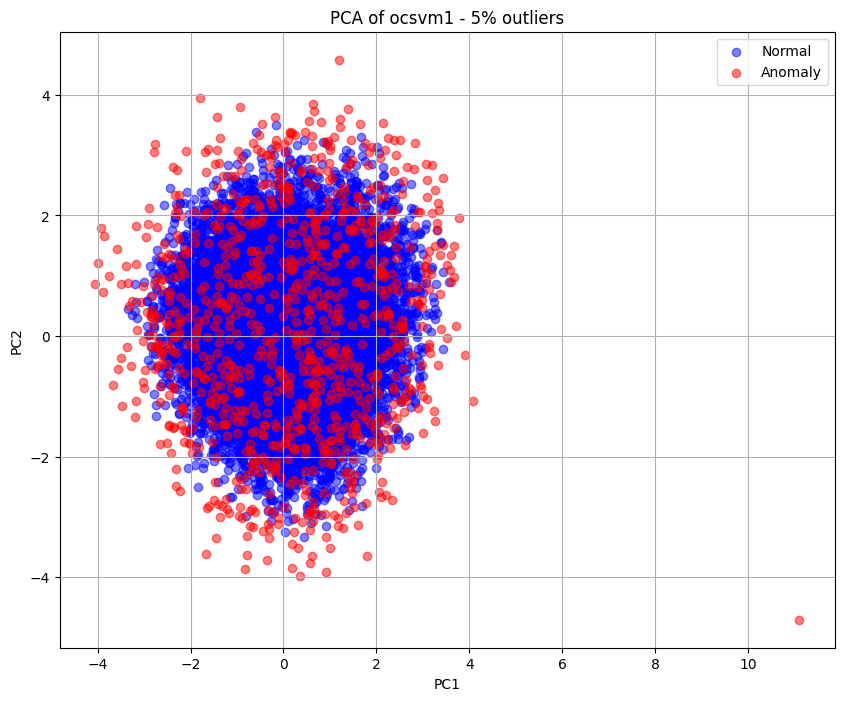

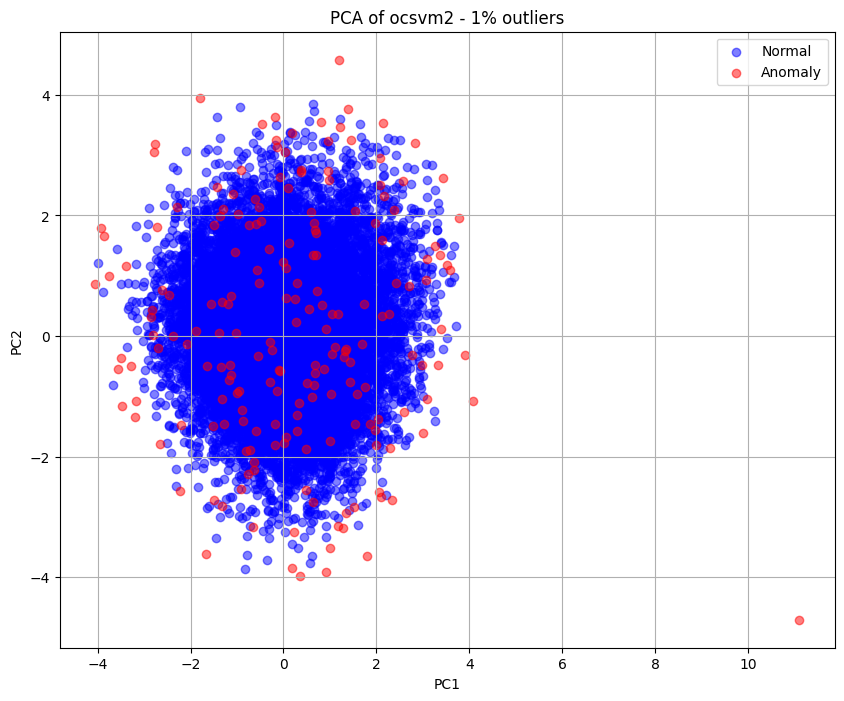

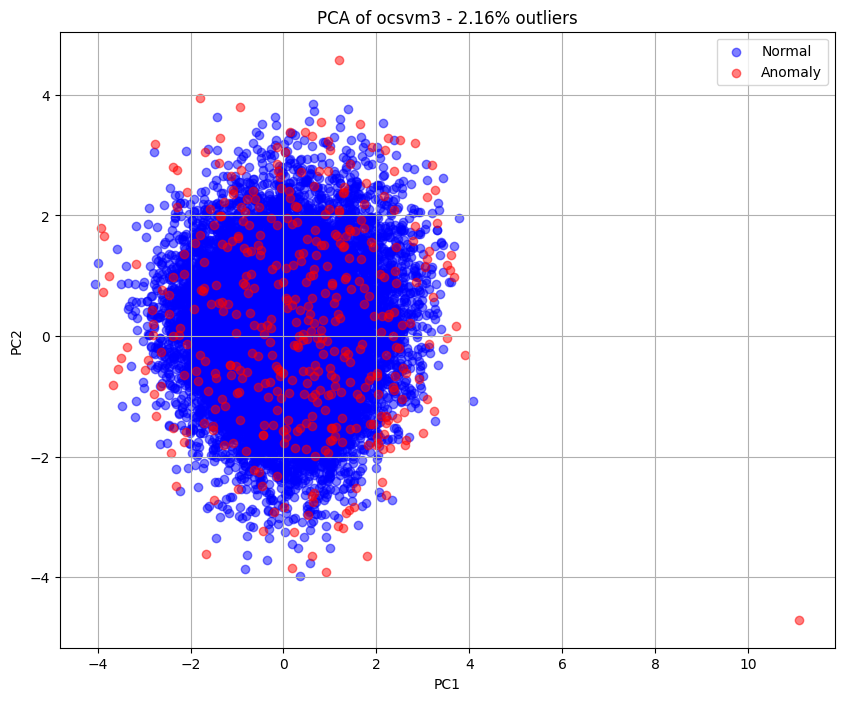

In [26]:
# Visualise the reduced data in 2D.
def plot_embedding(X, title, y_subset):
    plt.figure(figsize=(10, 8))

    plt.scatter(X[X['anomaly'] == 1]['PC1'],
                X[X['anomaly'] == 1]['PC2'],
                color='blue', label='Normal',alpha=0.5)
    plt.scatter(X[X['anomaly'] == -1]['PC1'],
                X[X['anomaly'] == -1]['PC2'],
            color='red', label='Anomaly',alpha=0.5)

    plt.xlabel('PC1')
    plt.ylabel('PC2')
    plt.legend()
    plt.title(title)
    plt.grid(True)
    plt.show()

plot_embedding(ocsvm_table1, "PCA of ocsvm1 - 5% outliers", y_pred_ocsvm1)
plot_embedding(ocsvm_table2, "PCA of ocsvm2 - 1% outliers", y_pred_ocsvm2)
plot_embedding(ocsvm_table3, "PCA of ocsvm3 - 2.16% outliers", y_pred_ocsvm3)

*Below has a breakdown of where the extreme value for PCA/OCSVM is positioned, across all three OCSVM tests with varying Gamma and Nu values. It is the row which has the Max value of the coolant temp. Interestingly, this is not considered an outlier basis spec from industry expert.

Extreme Visual Outlier - for results analysis of report

In [27]:
ocsvm_table1['PC1'].idxmax()
max_check = ocsvm_table1.iloc[10663]
print(max_check)

PC1        11.101810
PC2        -4.705312
anomaly    -1.000000
Name: 10663, dtype: float64


In [28]:
original_table_outlier = df_iqr.iloc[10663]
print(original_table_outlier)

Engine rpm                  455.000000
Lub oil pressure              2.010802
Fuel pressure                 7.806127
Coolant pressure              1.619575
lub oil temp                 76.519385
Coolant temp                195.527912
Engine rpm_outlier            0.000000
Lub oil pressure_outlier      0.000000
Fuel pressure_outlier         0.000000
Coolant pressure_outlier      0.000000
lub oil temp_outlier          0.000000
Coolant temp_outlier          1.000000
Name: 10663, dtype: float64


#4) Isolation Forest Method

In [29]:
iso_df = df.copy()

iso_forest1 = IsolationForest(n_estimators=100, contamination=0.05, random_state=42)
iso_forest2 = IsolationForest(n_estimators=100, contamination=0.01, random_state=42)
iso_forest3 = IsolationForest(n_estimators=100, contamination=0.0216, random_state=42)

iso_forest1.fit(iso_df)
iso_forest2.fit(iso_df)
iso_forest3.fit(iso_df)

IsolationForest(contamination=0.0216)

In [30]:
scores_pred = iso_forest1.decision_function(iso_df)
print(scores_pred)

[ 0.12403546 -0.02994844  0.04597591 ...  0.03027561  0.11209099
  0.15309425]


In [31]:
y_pred_iso1 = iso_forest1.predict(iso_df)
y_pred_iso2 = iso_forest2.predict(iso_df)
y_pred_iso3 = iso_forest3.predict(iso_df)

y_pred_iso1

array([ 1, -1,  1, ...,  1,  1,  1])

In [32]:
iso_table1 = df_pca.copy() #keeping df_pca separate so that anomaly values from other models i.e. Isolation Forest can be added onto it
iso_table2 = df_pca.copy() #keeping df_pca separate so that anomaly values from other models i.e. Isolation Forest can be added onto it
iso_table3 = df_pca.copy() #keeping df_pca separate so that anomaly values from other models i.e. Isolation Forest can be added onto it

iso_table1['anomaly'] = y_pred_iso1
iso_table2['anomaly'] = y_pred_iso2
iso_table3['anomaly'] = y_pred_iso3

iso_table1.describe()

,PC1,PC2,anomaly
count,1.953500e+04,1.953500e+04,19535.000000
mean,2.691588e-17,-2.400605e-17,0.899974
std,1.067590e+00,1.030355e+00,0.435954
min,-4.057396e+00,-4.705312e+00,-1.000000
25%,-7.233446e-01,-6.926878e-01,1.000000
50%,-2.191137e-02,-4.101296e-02,1.000000
75%,6.893994e-01,6.666201e-01,1.000000
max,1.110181e+01,4.582988e+00,1.000000


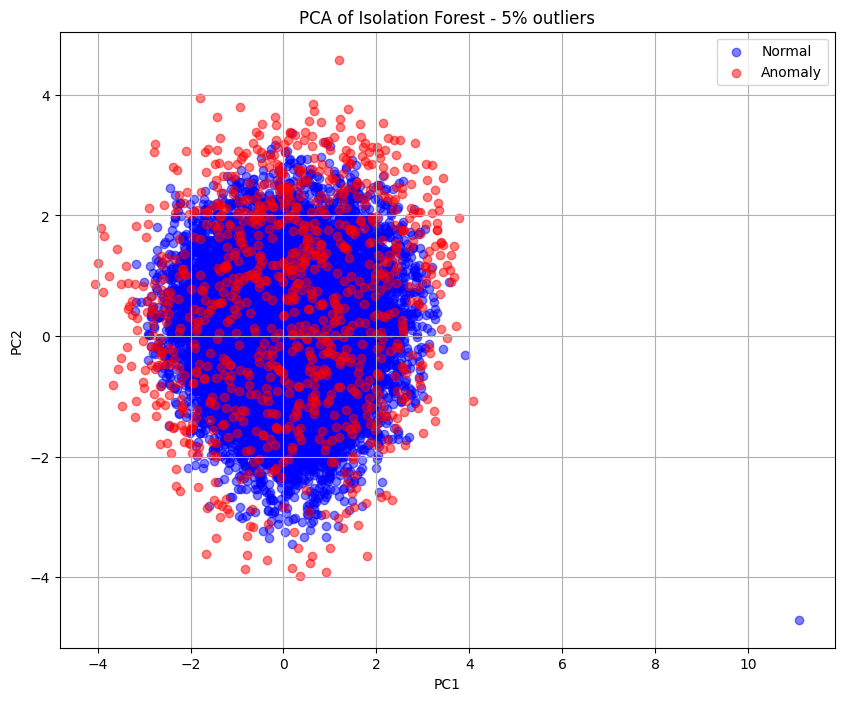

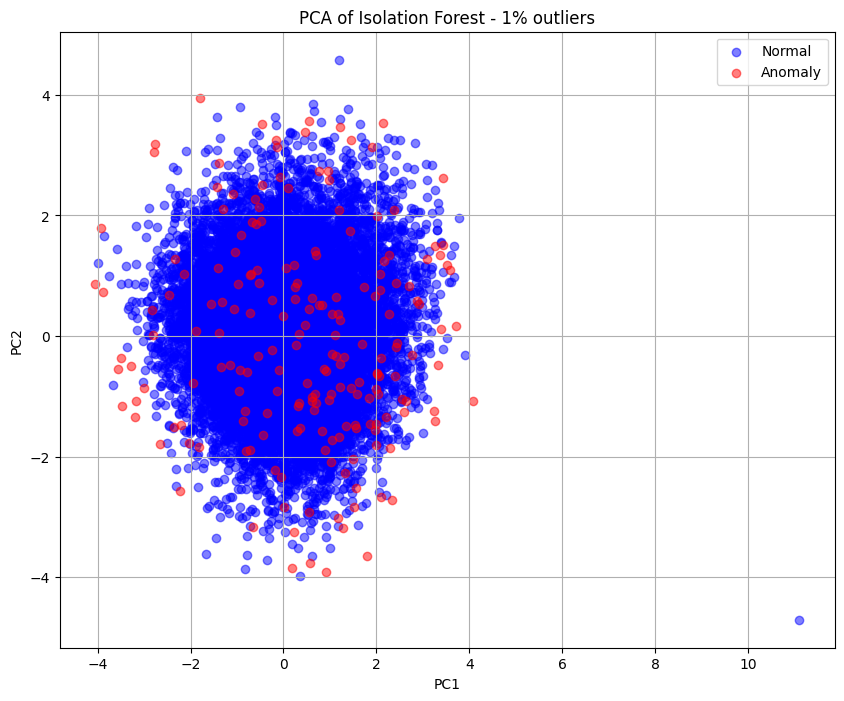

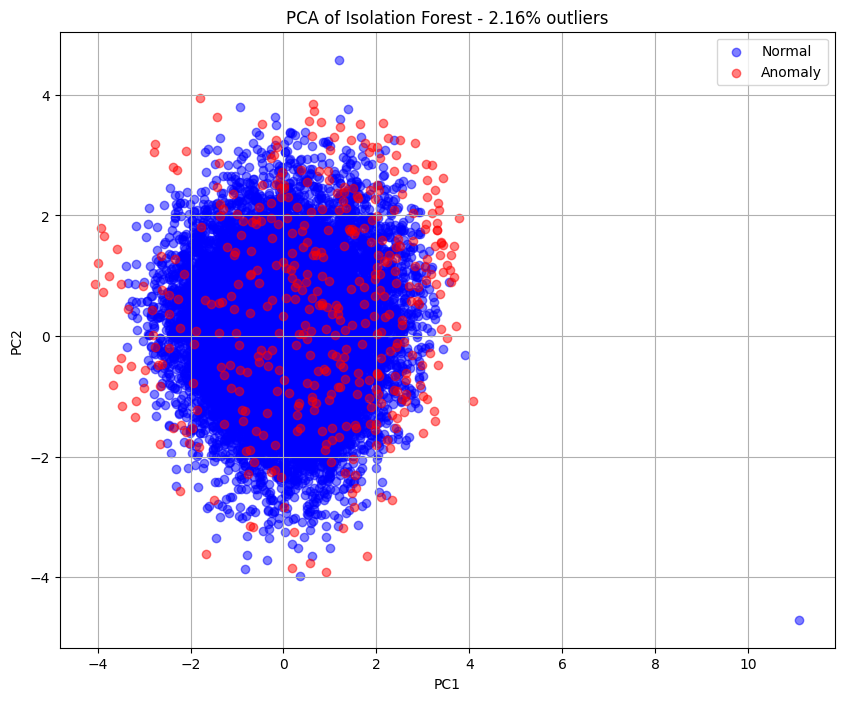

In [33]:
# Visualise the reduced data in 2D.
def plot_embedding(X, title, y_subset):
    plt.figure(figsize=(10, 8))

    plt.scatter(X[X['anomaly'] == 1]['PC1'],
                X[X['anomaly'] == 1]['PC2'],
                color='blue', label='Normal',alpha=0.5)
    plt.scatter(X[X['anomaly'] == -1]['PC1'],
                X[X['anomaly'] == -1]['PC2'],
            color='red', label='Anomaly',alpha=0.5)

    plt.xlabel('PC1')
    plt.ylabel('PC2')
    plt.legend()
    plt.title(title)
    plt.grid(True)
    plt.show()

plot_embedding(iso_table1, "PCA of Isolation Forest - 5% outliers", y_pred_iso1)
plot_embedding(iso_table2, "PCA of Isolation Forest - 1% outliers", y_pred_iso2)
plot_embedding(iso_table3, "PCA of Isolation Forest - 2.16% outliers", y_pred_iso3)

Isolation forest shows outlier to the far right as normal, differing from OCSVM method but matching with IQR method.

#5) Post Results Analysis

Below code goes through OCSVM and IF results, and applies a mask to each basis any anomaly result where both flagged them as an anomaly, basis index values. This mask is then applied to original IQR outlier table, to determine how many point for all three were raised as outliers

In [34]:
overall_anomalies1 = pd.DataFrame({'OCSVM1': y_pred_ocsvm1, 'IF1': y_pred_iso1})
mask1 = (overall_anomalies1['OCSVM1'] == -1) & (overall_anomalies1['IF1'] == -1)
overall_outliers1 = overall_anomalies1[mask1]

overall_anomalies2 = pd.DataFrame({'OCSVM2': y_pred_ocsvm2, 'IF2': y_pred_iso2})
mask2 = (overall_anomalies2['OCSVM2'] == -1) & (overall_anomalies2['IF2'] == -1)
overall_outliers2 = overall_anomalies2[mask2]

overall_anomalies3 = pd.DataFrame({'OCSVM3': y_pred_ocsvm3, 'IF3': y_pred_iso3})
mask3 = (overall_anomalies3['OCSVM3'] == -1) & (overall_anomalies3['IF3'] == -1)
overall_outliers3 = overall_anomalies3[mask3]

np.sum(mask2)
#overall_outliers2.describe()
#print(overall_outliers1)

np.int64(97)

In [35]:
IQR_mask1 = df_with_outliers.index.isin(overall_outliers1.index)
IQR_mask2 = df_with_outliers.index.isin(overall_outliers2.index)
IQR_mask3 = df_with_outliers.index.isin(overall_outliers3.index)

all_anomalies1 = df_with_outliers[IQR_mask1]
all_anomalies2 = df_with_outliers[IQR_mask2]
all_anomalies3 = df_with_outliers[IQR_mask3]

print("anomalies shared with all three models - 5% outliers :",len(all_anomalies1))
print("anomalies shared with all three models - 1% outliers :",len(all_anomalies2))
print("anomalies shared with all three models - 2.16% outliers :",len(all_anomalies3))

anomalies shared with all three models - 5% outliers : 211
anomalies shared with all three models - 1% outliers : 53
anomalies shared with all three models - 2.16% outliers : 55


### Reference:
Devabrat, M., 2022. Predictive Maintenance on Ship's Main Engine using AI. Available at: https://dx.doi.org/10.21227/g3za-v415. [Accessed 5 March 2024]